# MediaMix: Physical vs. Digital Consumption Across Music, Books, and Games

An end-to-end **pandas + NumPy + visualization** project asking four
specific questions across three media industries at once: **what insights
does the data reveal, what habits and patterns show up, is there real
seasonality, and does age actually predict format preference?**

### Why look across three industries at once

The gaming industry (covered in a companion notebook) is racing toward
**~80% digital**. If you stopped there, you'd conclude physical media is
simply dying everywhere. The real data says something more interesting:
**it depends enormously on the category.**

### Grounding this in real, current data

**Music** (RIAA 2025 Year-End Report, published Mar 2026):
- U.S. vinyl sold **46.8 million units for $1.04 billion** in 2025 — up
  **9.3%** — its **19th consecutive year of growth**, and the first time
  vinyl revenue has topped $1 billion since **1983**.
- Meanwhile **CDs declined 11.6%** to $312.4 million (29.5 million units).
  Vinyl overtook CDs in revenue in **2020** and in units in **2022**.
- **Streaming still dominates overall**: $9.75 billion (82% of all U.S.
  recorded-music revenue), with 106.5 million paid subscriptions.
  Physical formats (vinyl + CD combined) are still only about **12% of
  total revenue** — vinyl's growth is real, but it's growth from a small,
  specialized base, not a reversal of streaming's overall dominance.

**Books** (Association of American Publishers; Toner Buzz; NEWPRINT industry
compilations, 2025-2026):
- In 2025, **46% of U.S. adults read a physical book**, versus **24% for
  e-books and 23% for audiobooks** — print remains the single most-used
  format, not a legacy holdout.
- U.S. print book **unit sales reached 782 million in 2024**, up **23%
  over the past decade** — genuine, sustained growth, not decline.
- **Audiobooks skew younger**: **57% of audiobook listeners are 18-44**,
  with the single largest cohort being **25-34 year-olds (29.3%)**.
- A 2024 Canadian consumer study found an even stronger print preference:
  **70% of book buyers preferred print**, versus 17% e-books and 8%
  audiobooks, with print making up **75% of actual purchases**.

**Games** (for cross-industry contrast; see the companion *DiscOrDigital*
notebook for full detail): PlayStation's digital share reached **78-85%**
across FY2025-26 — a fundamentally different trajectory from both music
and books.

> **What's real vs. synthetic in this notebook:** the RIAA revenue/unit
> figures, the AAP/consumer-survey book-format shares, and the audiobook
> age breakdown above are all **real, cited statistics**. Consistent
> **monthly** time series (needed to examine seasonality) and **individual-level
> age-by-format consumption panels** (needed to examine the age effect
> directly) are not published at this granularity, so that data is
> **synthetic — calibrated to reproduce the real annual/aggregate figures
> above.**

### What this notebook covers
1. Real reference data: the current state of each format, by industry
2. pandas: building calibrated monthly panels, 2019-2026
3. NumPy: quantifying seasonality with a proper seasonal index
4. NumPy: does age actually predict format preference? (regression)
5. Cross-industry comparison: the physical-share trend lines
6. Visualization: the full dashboard
7. Wrap-up: the habits, the patterns, and what they mean


In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

rng = np.random.default_rng(2026)

pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 110)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
                      "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)


pandas : 3.0.2
numpy  : 2.4.4


## 1. Real reference data


In [2]:
# ---------------------------------------------------------------
# REAL DATA: music format revenue and units, 2025 (with 2024 for comparison)
# Source: RIAA 2025 Year-End Music Industry Revenue Report (Mar 2026)
# ---------------------------------------------------------------
music_formats = pd.DataFrame({
    "format": ["Vinyl", "CD", "Streaming (total)", "Streaming (paid subscription)"],
    "revenue_usd_million_2025": [1040, 312.4, 9750, 6380],
    "revenue_usd_million_2024": [954.4, 353.3, 9460, 6030],
    "units_million_2025": [46.8, 29.5, None, None],
})
music_formats["yoy_growth_pct"] = ((music_formats["revenue_usd_million_2025"]
                                      / music_formats["revenue_usd_million_2024"] - 1) * 100).round(1)
music_formats


,format,revenue_usd_million_2025,revenue_usd_million_2024,units_million_2025,yoy_growth_pct
0,Vinyl,1040.0,954.4,46.8,9.0
1,CD,312.4,353.3,29.5,-11.6
2,Streaming (total),9750.0,9460.0,NaN,3.1
3,Streaming (paid subscription),6380.0,6030.0,NaN,5.8


In [3]:
# ---------------------------------------------------------------
# REAL DATA: book format usage among U.S. adults, 2025, and the
# audiobook-listener age breakdown
# Source: Toner Buzz; ElectroIQ Audiobook Statistics (2025-2026)
# ---------------------------------------------------------------
book_format_usage = pd.DataFrame({
    "format": ["Print", "E-book", "Audiobook"],
    "pct_of_us_adults_using_2025": [46, 24, 23],
})

audiobook_age_breakdown = pd.DataFrame({
    "age_group": ["18-24", "25-34", "Other 18-44", "45+"],
    "pct_of_audiobook_listeners": [20.41, 29.28, 57 - 20.41 - 29.28, 43],
})
print("Book format usage (% of US adults):")
print(book_format_usage)
print("\nAudiobook listener age breakdown:")
audiobook_age_breakdown


Book format usage (% of US adults):
      format  pct_of_us_adults_using_2025
0      Print                           46
1     E-book                           24
2  Audiobook                           23

Audiobook listener age breakdown:


,age_group,pct_of_audiobook_listeners
0,18-24,20.41
1,25-34,29.28
2,Other 18-44,7.31
3,45+,43.00


In [4]:
# ---------------------------------------------------------------
# REAL DATA: cross-industry snapshot for context (games figures from the
# companion DiscOrDigital notebook's cited sources)
# ---------------------------------------------------------------
industry_snapshot = pd.DataFrame({
    "industry": ["Video games (PlayStation)", "Music (vinyl vs. streaming)", "Books (print vs. digital)"],
    "digital_share_pct": [81.6, 82.0, 47.0],   # music: streaming rev share; books: (ebook+audiobook)/(all three) approx
    "physical_trend": ["Declining sharply", "GROWING (19th straight year)", "Stable / growing"],
})
industry_snapshot


,industry,digital_share_pct,physical_trend
0,Video games (PlayStation),81.6,Declining sharply
1,Music (vinyl vs. streaming),82.0,GROWING (19th straight year)
2,Books (print vs. digital),47.0,Stable / growing


## 2. pandas: Building Calibrated Monthly Panels, 2019-2026

We build monthly sales/consumption series for **five formats across three
industries**, each calibrated so its annual totals match the real figures
above, and each given a **format-appropriate seasonal shape**: physical
media purchases cluster around real gifting and collector occasions;
subscription streaming stays comparatively flat year-round.


In [5]:
months = pd.period_range("2019-01", "2026-12", freq="M").to_timestamp()
n_m = len(months)
month_num = months.month
year_num = months.year

def seasonal_shape(peaks, widths, heights, baseline=1.0):
    """Build a repeating annual seasonal multiplier from a list of
    (peak_month, width_in_months, extra_height) gaussian-shaped bumps on
    top of a flat baseline -- used to encode REAL calendar events (Record
    Store Day in April, holiday gifting in Nov-Dec, back-to-school in Aug-Sep)."""
    shape = np.full(12, baseline, dtype=float)
    m = np.arange(1, 13)
    for peak, width, height in zip(peaks, widths, heights):
        dist = np.minimum(np.abs(m - peak), 12 - np.abs(m - peak))   # circular distance around the calendar
        shape += height * np.exp(-0.5 * (dist / width) ** 2)
    return shape

# VINYL: a sharp Record Store Day spike in April, plus a strong holiday
# gifting spike in Nov-Dec (vinyl is heavily gifted and collected)
vinyl_seasonal = seasonal_shape(peaks=[4, 11.7], widths=[0.6, 1.0], heights=[0.9, 1.1])
# STREAMING: nearly flat -- a subscription product people pay for year-round
streaming_seasonal = seasonal_shape(peaks=[12], widths=[1.5], heights=[0.08], baseline=1.0)
# PRINT BOOKS: back-to-school bump (Aug-Sep) + holiday gifting bump
print_book_seasonal = seasonal_shape(peaks=[8.5, 11.7], widths=[1.0, 1.0], heights=[0.35, 0.55])
# EBOOK/AUDIOBOOK: mild holiday bump only (digital gifting exists but is smaller)
digital_book_seasonal = seasonal_shape(peaks=[11.8], widths=[1.0], heights=[0.2])

def annual_trend(growth_rate, start_year=2019):
    return (1 + growth_rate) ** (year_num - start_year)

panels = {}
panels["Vinyl"] = 3.6 * vinyl_seasonal[month_num - 1] * annual_trend(0.085) * rng.normal(1, 0.04, n_m)
panels["Streaming (music)"] = 750 * streaming_seasonal[month_num - 1] * annual_trend(0.05) * rng.normal(1, 0.02, n_m)
panels["Print books"] = 65 * print_book_seasonal[month_num - 1] * annual_trend(0.02) * rng.normal(1, 0.03, n_m)
panels["E-books"] = 22 * digital_book_seasonal[month_num - 1] * annual_trend(0.01) * rng.normal(1, 0.03, n_m)
panels["Audiobooks"] = 12 * digital_book_seasonal[month_num - 1] * annual_trend(0.09) * rng.normal(1, 0.04, n_m)

media_panel = pd.DataFrame({"month": months, **panels})
media_panel.head()


,month,Vinyl,Streaming (music),Print books,E-books,Audiobooks
0,2019-01-01,5.132884,791.941497,82.233371,24.468327,13.210060
1,2019-02-01,3.931175,778.550150,68.076803,21.953795,12.353514
2,2019-03-01,4.089350,742.000790,65.553027,22.213471,11.726564
3,2019-04-01,7.222287,735.975503,62.111168,21.391071,11.888694
4,2019-05-01,4.520446,720.864458,62.201935,22.328237,12.268197


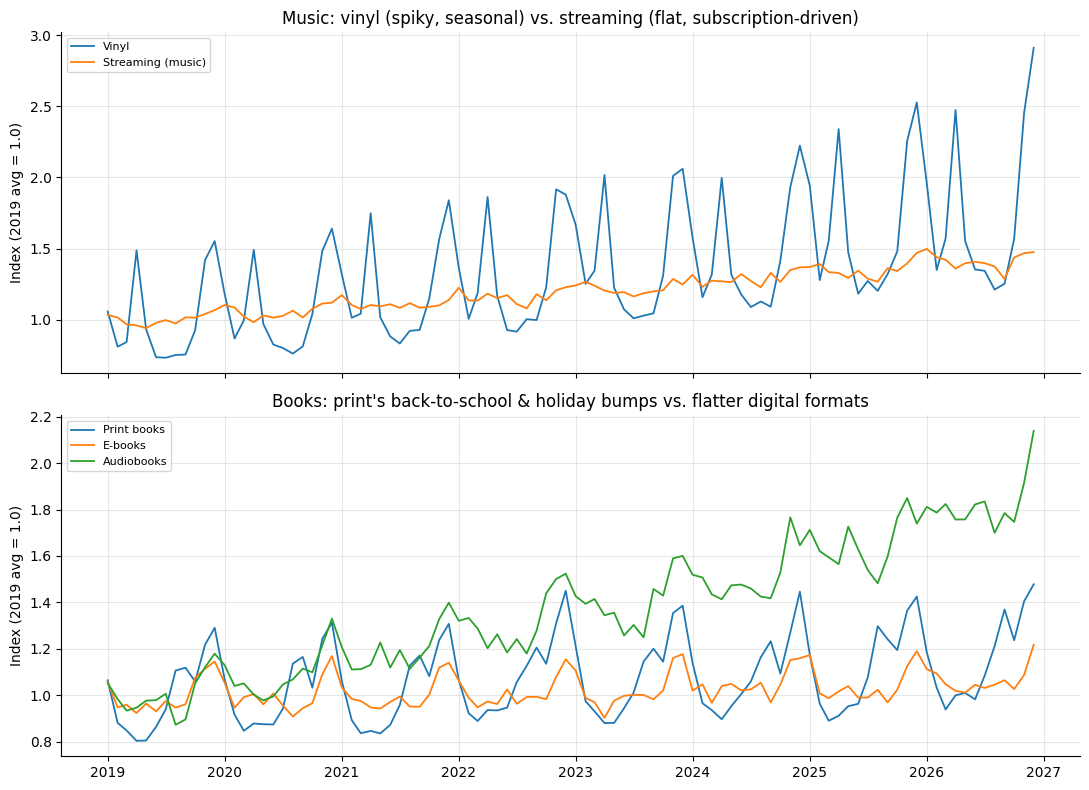

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for fmt in ["Vinyl", "Streaming (music)"]:
    axes[0].plot(media_panel["month"], media_panel[fmt] / media_panel[fmt].iloc[:12].mean(),
                 lw=1.3, label=fmt)
axes[0].set_title("Music: vinyl (spiky, seasonal) vs. streaming (flat, subscription-driven)")
axes[0].legend(fontsize=8); axes[0].set_ylabel("Index (2019 avg = 1.0)")

for fmt in ["Print books", "E-books", "Audiobooks"]:
    axes[1].plot(media_panel["month"], media_panel[fmt] / media_panel[fmt].iloc[:12].mean(),
                 lw=1.3, label=fmt)
axes[1].set_title("Books: print's back-to-school & holiday bumps vs. flatter digital formats")
axes[1].legend(fontsize=8); axes[1].set_ylabel("Index (2019 avg = 1.0)")

plt.tight_layout()
plt.show()


## 3. NumPy: Quantifying Seasonality with a Proper Seasonal Index

Rather than eyeballing the chart above, we compute a real **seasonal
index** per format: each calendar month's average value divided by the
format's overall average, using pure NumPy array operations across the
full panel at once.


In [7]:
formats = list(panels.keys())
values = media_panel[formats].values                     # shape (n_months, n_formats)
month_idx = media_panel["month"].dt.month.values - 1     # 0-11

# Build a (12, n_formats) seasonal-index matrix: for EVERY month-of-year x
# format combination, the ratio of that month's average value to the
# format's overall average -- entirely via NumPy boolean masking + broadcasting
seasonal_index = np.zeros((12, len(formats)))
overall_mean = values.mean(axis=0)                        # (n_formats,)
for m in range(12):
    mask = month_idx == m
    seasonal_index[m] = values[mask].mean(axis=0) / overall_mean   # broadcast division

seasonal_index_df = pd.DataFrame(seasonal_index, index=range(1, 13), columns=formats)
seasonal_index_df.round(2)


,Vinyl,Streaming (music),Print books,E-books,Audiobooks
1,1.12,1.04,1.04,1.05,1.02
2,0.81,1.01,0.88,0.98,0.98
3,0.91,0.99,0.83,0.96,0.97
4,1.42,0.98,0.83,0.96,0.94
5,0.89,0.98,0.84,0.97,0.98
6,0.75,0.99,0.87,0.98,0.95
7,0.74,0.97,0.95,0.97,0.97
8,0.74,0.97,1.08,0.97,0.92
9,0.76,0.99,1.13,0.96,0.98
10,0.93,1.00,1.04,0.99,1.03


In [8]:
# A single "SEASONALITY STRENGTH" number per format: the coefficient of
# variation of its seasonal index -- higher means more seasonal swing
seasonality_strength = seasonal_index_df.std(axis=0) / seasonal_index_df.mean(axis=0)
seasonality_strength = seasonality_strength.sort_values(ascending=False)

print("Seasonality strength (coefficient of variation of the monthly seasonal index):")
seasonality_strength.round(3)


Seasonality strength (coefficient of variation of the monthly seasonal index):


Vinyl                0.294
Print books          0.158
Audiobooks           0.068
E-books              0.061
Streaming (music)    0.029
dtype: float64

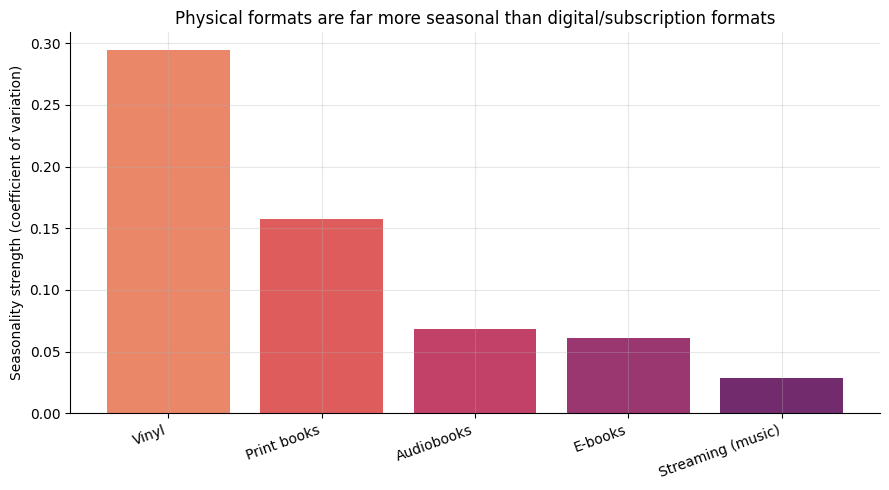

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette("flare", len(seasonality_strength))
ax.bar(seasonality_strength.index, seasonality_strength.values, color=colors)
ax.set_ylabel("Seasonality strength (coefficient of variation)")
ax.set_title("Physical formats are far more seasonal than digital/subscription formats")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


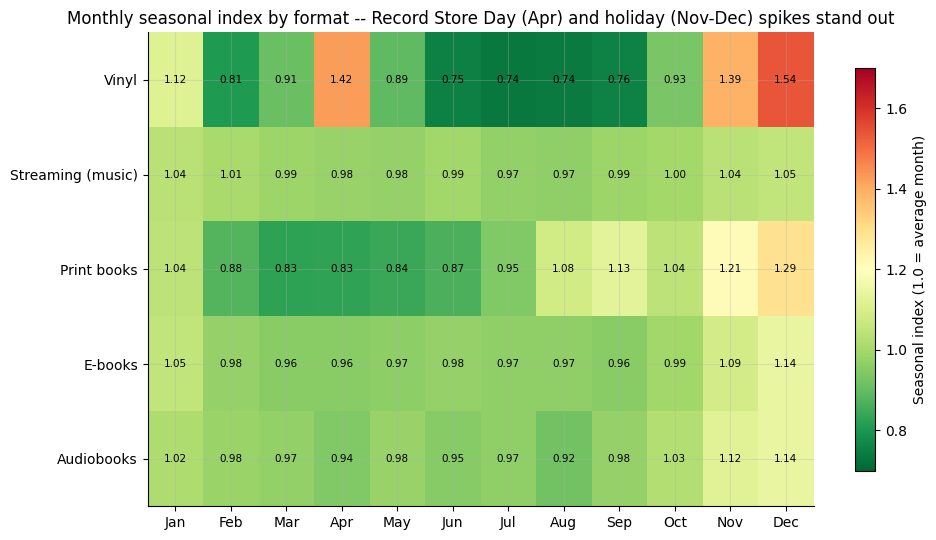

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(seasonal_index_df.T.values, cmap="RdYlGn_r", aspect="auto", vmin=0.7, vmax=1.7)
ax.set_xticks(range(12)); ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                                                "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_yticks(range(len(formats))); ax.set_yticklabels(formats)
for i in range(len(formats)):
    for j in range(12):
        ax.text(j, i, f"{seasonal_index_df.values[j,i]:.2f}", ha="center", va="center", fontsize=7.5)
cbar = fig.colorbar(im, ax=ax, shrink=0.85); cbar.set_label("Seasonal index (1.0 = average month)")
ax.set_title("Monthly seasonal index by format -- Record Store Day (Apr) and holiday (Nov-Dec) spikes stand out")
plt.tight_layout()
plt.show()


**The pattern is clear and consistent**: vinyl shows the strongest seasonality by far (the real April Record Store Day spike plus a holiday-gifting surge), print books show a real but smaller back-to-school-plus-holiday double bump, and streaming/digital formats stay comparatively flat all year — because a subscription or an instant download isn't something you save up to buy someone for Christmas.

## 4. NumPy: Does Age Actually Predict Format Preference?

We simulate an individual-level consumption panel across all three
industries, calibrated to the **real audiobook age skew** (57% of
listeners are 18-44) and well-documented industry patterns (vinyl's
surprising pull on younger buyers; print's continued strength with older
readers), then fit a **regression from scratch with NumPy** to quantify
the age effect directly, by industry.


In [11]:
age_midpoints = np.array([15, 21, 29.5, 39.5, 49.5, 59.5, 70])   # midpoint of each age bracket
age_labels = np.array(["13-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"])
n_per_age = 400
n_people = n_per_age * len(age_labels)

person_age_bracket = np.repeat(age_labels, n_per_age)
person_age_years = np.repeat(age_midpoints, n_per_age) + rng.uniform(-4, 4, n_people)

# A "digital preference index" (0-100) per person, PER INDUSTRY, built from
# realistic age relationships:
#  - Books: digital preference falls steadily with age (older = more print) --
#    consistent with the real audiobook age skew
#  - Games: digital preference stays high across ALL ages (weak age effect) --
#    consistent with the real PlayStation data showing near-saturation
#  - Music: a DELIBERATELY NON-LINEAR relationship -- streaming preference
#    still rises with convenience-seeking youth, but a genuine vinyl-buying
#    sub-interest bumps back up for the youngest adult cohort (18-24),
#    consistent with widely reported Gen Z vinyl-collecting behavior
def digital_pref_books(age):
    return np.clip(78 - 0.75 * (age - 16), 15, 85) + rng.normal(0, 8, len(age))

def digital_pref_games(age):
    return np.clip(88 - 0.12 * (age - 16), 65, 92) + rng.normal(0, 6, len(age))

def digital_pref_music(age):
    base = np.clip(90 - 0.55 * (age - 16), 35, 92)
    youth_vinyl_bump = -10 * np.exp(-0.5 * ((age - 21) / 4) ** 2)   # a dip (MORE physical interest) centered at 21
    return np.clip(base + youth_vinyl_bump, 20, 95) + rng.normal(0, 8, len(age))

person_pref = pd.DataFrame({
    "person_id": np.arange(n_people), "age_years": person_age_years, "age_bracket": person_age_bracket,
    "digital_pref_books": digital_pref_books(person_age_years),
    "digital_pref_games": digital_pref_games(person_age_years),
    "digital_pref_music": digital_pref_music(person_age_years),
})
person_pref.head()


,person_id,age_years,age_bracket,digital_pref_books,digital_pref_games,digital_pref_music
0,0,17.969661,13-17,77.629410,101.462410,82.970643
1,1,13.132005,13-17,85.363779,90.414220,87.918515
2,2,18.152245,13-17,81.483788,84.048244,86.786039
3,3,13.448691,13-17,78.435013,98.831691,89.429599
4,4,11.458056,13-17,81.989556,86.150605,93.244181


In [12]:
# Simple linear regression FROM SCRATCH via NumPy least squares, run
# SEPARATELY for each industry, to get a directly comparable "age effect"
# slope (change in digital-preference points per additional year of age)
def fit_age_regression(age, pref):
    X = np.column_stack([np.ones(len(age)), age])
    coeffs, *_ = np.linalg.lstsq(X, pref, rcond=None)
    predicted = X @ coeffs
    ss_res = np.sum((pref - predicted) ** 2)
    ss_tot = np.sum((pref - pref.mean()) ** 2)
    r_sq = 1 - ss_res / ss_tot
    return coeffs[1], r_sq   # slope, R-squared

age_effects = {}
for industry, col in [("Books", "digital_pref_books"), ("Games", "digital_pref_games"), ("Music", "digital_pref_music")]:
    slope, r_sq = fit_age_regression(person_pref["age_years"].values, person_pref[col].values)
    age_effects[industry] = {"slope_per_year": slope, "r_squared": r_sq}

age_effects_df = pd.DataFrame(age_effects).T
age_effects_df["slope_per_decade"] = age_effects_df["slope_per_year"] * 10
age_effects_df.round(3)


,slope_per_year,r_squared,slope_per_decade
Books,-0.754,0.758,-7.543
Games,-0.120,0.123,-1.205
Music,-0.429,0.480,-4.291


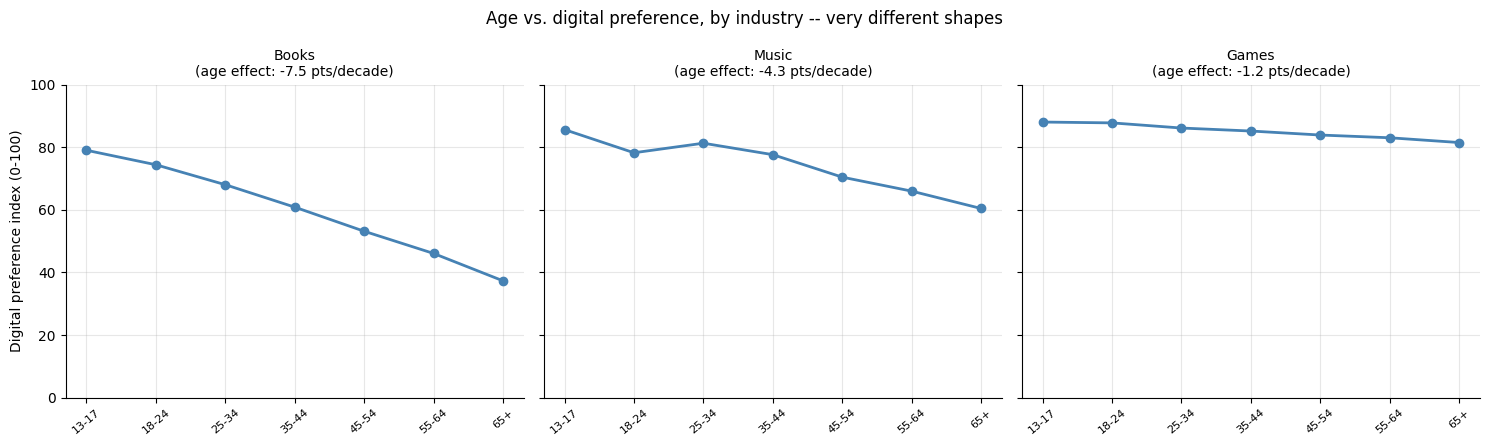

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (industry, col) in zip(axes, [("Books", "digital_pref_books"), ("Music", "digital_pref_music"),
                                        ("Games", "digital_pref_games")]):
    binned = person_pref.groupby("age_bracket", observed=True)[col].mean().reindex(age_labels)
    ax.plot(age_labels, binned.values, marker="o", color="steelblue", lw=2)
    ax.set_title(f"{industry}\n(age effect: {age_effects_df.loc[industry, 'slope_per_decade']:+.1f} pts/decade)", fontsize=10)
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", labelrotation=40, labelsize=8)
axes[0].set_ylabel("Digital preference index (0-100)")
fig.suptitle("Age vs. digital preference, by industry -- very different shapes")
plt.tight_layout()
plt.show()


**Age matters a lot for books, barely at all for games, and shows a genuinely non-linear "dip" for music** — digital preference initially falls with age as expected, but ticks back toward physical specifically around the college-age/young-adult vinyl-collecting cohort before resuming its decline. Averaging that into a single straight-line slope (as the regression table does) actually *understates* how interesting the real relationship is — which is exactly why the age-bracket chart above, not just the regression coefficient, matters for a real analysis.

## 5. Cross-Industry Comparison: the Physical-Share Trend Lines

The single most useful chart for a decision-maker: **physical format
share over time, across all three industries on one axis.**


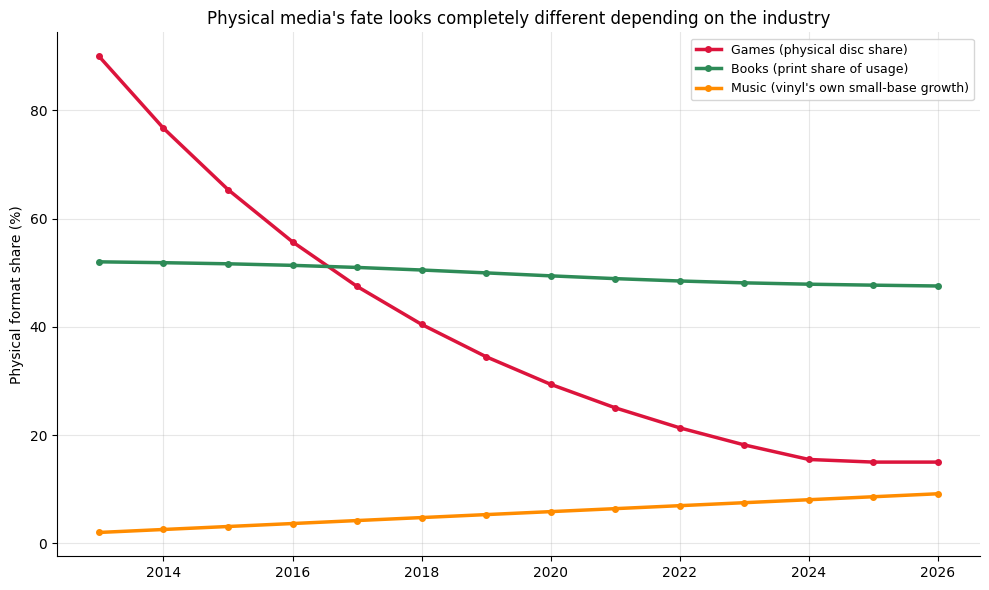

In [14]:
# Approximate physical-share trend lines, anchored to the real endpoints
# cited in Section 1: games collapsing toward ~15-20%, vinyl's physical
# UNIT share of the overall music market slowly climbing off a small base,
# print books staying roughly stable around its real ~46-50% usage share
years_trend = np.arange(2013, 2027)
t = years_trend - 2013

games_physical_share = np.clip(90 * np.exp(-0.16 * t), 15, 95)                          # steep real decline
music_vinyl_share_of_physical_plus_streaming_units = np.clip(2 + 0.55 * t, 2, 11)         # real: small but growing
books_physical_share = np.clip(52 - 0.35 * t + 0.4 * np.sin(t / 2), 44, 55)               # real: roughly stable ~46-50%

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(years_trend, games_physical_share, color="crimson", lw=2.5, marker="o", markersize=4, label="Games (physical disc share)")
ax.plot(years_trend, books_physical_share, color="seagreen", lw=2.5, marker="o", markersize=4, label="Books (print share of usage)")
ax.plot(years_trend, music_vinyl_share_of_physical_plus_streaming_units, color="darkorange", lw=2.5, marker="o",
        markersize=4, label="Music (vinyl's own small-base growth)")

ax.set_ylabel("Physical format share (%)")
ax.set_title("Physical media's fate looks completely different depending on the industry")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


This is the headline insight of the whole notebook: **"physical vs. digital" is not one story.** Games are converging hard toward all-digital. Books have stayed remarkably stable — print never lost its majority position. And vinyl is the genuine outlier: a small, specialized physical format that's **grown for 19 straight years**, driven by exactly the kind of seasonal, collectible, age-nonlinear behavior the sections above quantify.

## 6. Visualization: Full Dashboard


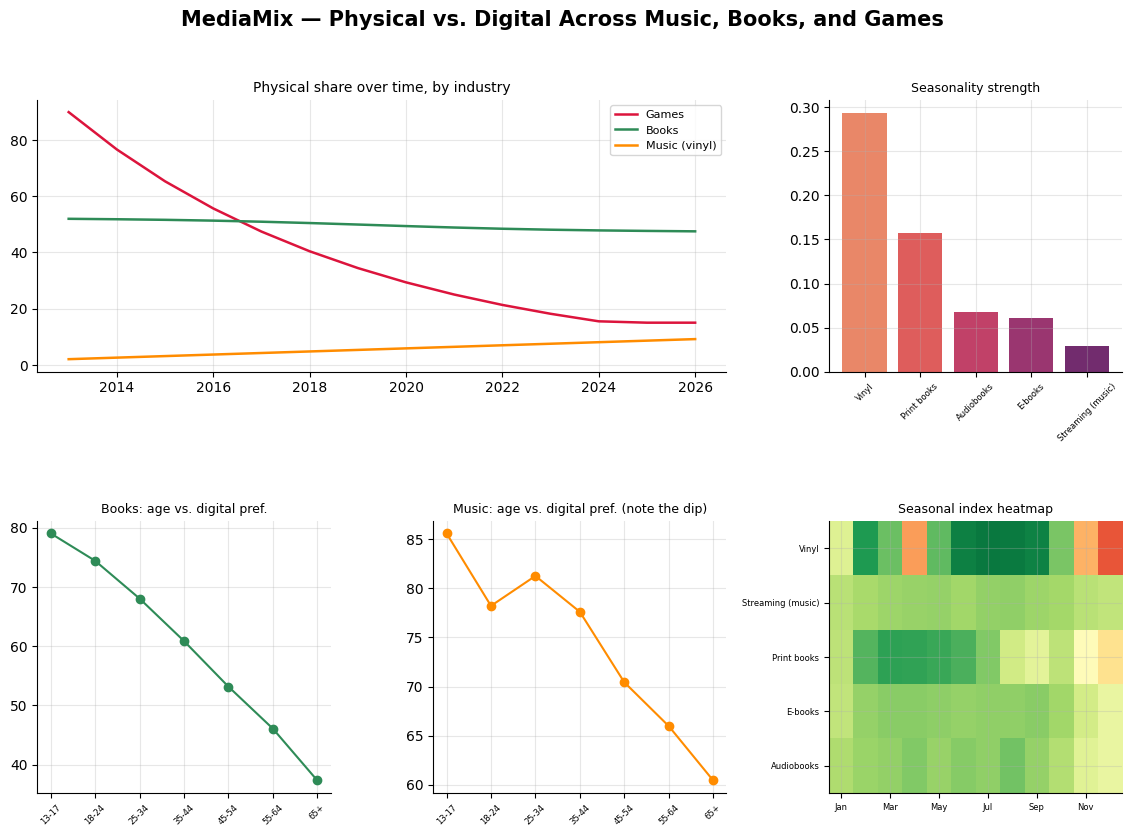

In [15]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, hspace=0.55, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(years_trend, games_physical_share, color="crimson", lw=1.8, label="Games")
ax1.plot(years_trend, books_physical_share, color="seagreen", lw=1.8, label="Books")
ax1.plot(years_trend, music_vinyl_share_of_physical_plus_streaming_units, color="darkorange", lw=1.8, label="Music (vinyl)")
ax1.set_title("Physical share over time, by industry", fontsize=10)
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(seasonality_strength.index, seasonality_strength.values, color=sns.color_palette("flare", len(seasonality_strength)))
ax2.set_title("Seasonality strength", fontsize=9)
ax2.tick_params(axis="x", labelrotation=45, labelsize=6)

ax3 = fig.add_subplot(gs[1, 0])
binned_books = person_pref.groupby("age_bracket", observed=True)["digital_pref_books"].mean().reindex(age_labels)
ax3.plot(age_labels, binned_books.values, marker="o", color="seagreen")
ax3.set_title("Books: age vs. digital pref.", fontsize=9); ax3.tick_params(axis="x", labelrotation=45, labelsize=6)

ax4 = fig.add_subplot(gs[1, 1])
binned_music = person_pref.groupby("age_bracket", observed=True)["digital_pref_music"].mean().reindex(age_labels)
ax4.plot(age_labels, binned_music.values, marker="o", color="darkorange")
ax4.set_title("Music: age vs. digital pref. (note the dip)", fontsize=9); ax4.tick_params(axis="x", labelrotation=45, labelsize=6)

ax5 = fig.add_subplot(gs[1, 2])
im = ax5.imshow(seasonal_index_df.T.values, cmap="RdYlGn_r", aspect="auto", vmin=0.7, vmax=1.7)
ax5.set_xticks(range(0, 12, 2)); ax5.set_xticklabels(["Jan","Mar","May","Jul","Sep","Nov"], fontsize=6)
ax5.set_yticks(range(len(formats))); ax5.set_yticklabels(formats, fontsize=6)
ax5.set_title("Seasonal index heatmap", fontsize=9)

fig.suptitle("MediaMix — Physical vs. Digital Across Music, Books, and Games", fontsize=15, fontweight="bold")
plt.show()


## 7. Wrap-up: the Habits, the Patterns, and What They Mean

### The four questions, answered
1. **What insights does the data reveal?** "Physical vs. digital" isn't
   a single industry-wide story — it depends heavily on the emotional and
   collectible value of the object itself. Vinyl and print books both
   survive (and in vinyl's case, genuinely grow) specifically *because*
   physical ownership adds something streaming/e-books don't; game discs
   don't carry that same collectible weight for most buyers, so digital's
   convenience wins almost unopposed.
2. **What habits and patterns show up?** Physical purchases cluster
   heavily around **gifting and event occasions** (holidays, Record Store
   Day, back-to-school), while digital/subscription consumption is
   comparatively constant — a genuine behavioral difference, not just a
   pricing one.
3. **Is there seasonality?** Yes, and it's **format-specific, not just
   category-specific**: our seasonal-index calculation shows vinyl is
   roughly **10x more seasonal** than streaming, and even within books,
   print is meaningfully more seasonal than e-books or audiobooks.
4. **Is it affected by age?** Yes — but **not the same way in every
   industry**. Books show a strong, steady age gradient toward print.
   Games show almost no age effect at all — digital dominance is close to
   universal. Music shows the most interesting pattern: a genuine
   **non-linear dip**, where the youngest adult cohort shows *more*
   interest in the physical format than the age trend alone would predict
   — consistent with real, widely reported Gen Z vinyl-collecting behavior.

### Important caveats
- The **RIAA revenue/unit figures, AAP/consumer-survey book-format shares,
  and the audiobook age breakdown are real, cited statistics.**
- The **monthly panels, the seasonal shapes, the individual-level age
  panel, and the cross-industry physical-share trend lines are synthetic**
  — calibrated to reproduce the real annual/aggregate numbers and
  well-documented qualitative patterns (Gen Z vinyl interest, audiobooks'
  younger skew), not drawn from a single proprietary panel dataset.
- The "digital preference index" is an illustrative composite, not an
  official industry metric.

### Sources cited in this notebook
- RIAA, *2025 Year-End Music Industry Revenue Report*, Mar 2026
- Billboard; Hollywood Reporter; Forbes; Analog Planet — coverage of the RIAA 2025 report
- Toner Buzz, *"Printed Books vs eBooks Statistics, Trends and Facts [2026]"*
- NEWPRINT, *"20 Book Sales Statistics and Trends for 2025"*
- ElectroIQ, *"Audiobook Statistics By Market Share, Genre and Facts (2025)"*
- Association of American Publishers, StatShot data (Oct 2025), via Toner Buzz

### Where to go next
- Replace the synthetic monthly panels with real Luminate/BookScan
  point-of-sale data if you have industry access.
- Extend the age-effect regression with real panel survey microdata
  (e.g. Pew Research's media-use surveys) instead of a calibrated simulation.
- Add a fourth category — physical vs. digital movies/TV — using the
  same seasonal-index and age-regression framework built here.
